# Data Loading and Preparation

## Basic Imports

In [280]:
# Data handling
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Pathing
from pathlib import Path

# Modelling
from sklearn.model_selection import train_test_split
import joblib

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, average_precision_score, roc_curve, roc_auc_score

# Make plots look nicer
sns.set_theme(style="whitegrid")
%matplotlib inline

## Load Processed Feature Dataset for Evaluation

In [282]:
df_eval = pd.read_csv("../data/processed/stage1_full.csv", low_memory=False) # Read full DataFrame (contains ALL features)
print("Loaded dataset shape:", df_eval.shape)
display(df_eval.head())

Loaded dataset shape: (2540047, 56)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_dst_src_ltm,attack_cat,Label,log_dbytes,log_min_flow_bytes,log_byte_prod,load_skew,log_dmeansz,mean_pkt_sz_ratio,ttl_diff
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,1,NaN,0,5.105945,4.890349,9.982715,1.016540,4.418841,1.050930,2
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,2,NaN,0,5.720312,5.720312,11.986130,0.951495,4.343805,0.888240,2
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,1,NaN,0,5.187386,4.990433,10.165429,1.015053,4.499810,1.045479,2
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,1,NaN,0,5.105945,4.890349,9.982715,1.016714,4.418841,1.050930,2
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,1,NaN,0,5.187386,4.990433,10.165429,1.015103,4.499810,1.045479,2


## Train/Test Split

In [284]:
# Recreate training notebook test set exactly
_, df_test = train_test_split(
    df_eval, test_size=0.2, stratify=df_eval["Label"], random_state=42
)

# Load list of features
stage1_selected_features_path = Path("../data/processed/stage1_selected_features.pkl")
stage1_selected_features = joblib.load(stage1_selected_features_path)

# Feed only selected features to model
X_test = df_test[stage1_selected_features]
y_test = df_test["Label"]

## Load Model From Disk

In [285]:
model_path = Path("../models/isolation_forest_pipeline.pkl")
model = joblib.load(model_path)
print(f"Model retrieved from {model_path}.")

Model retrieved from ../models/isolation_forest_pipeline.pkl.


# Model Evaluation

## Isolation Forest Model

### Generate Predictions and Anomaly Scores

In [287]:
anomaly_scores = -model.decision_function(X_test)
pred_labels = model.predict(X_test)
pred_labels_binary = (pred_labels == -1).astype(int)

df_test["Label"] = y_test
df_test["anomaly_score"] = anomaly_scores
df_test["pred_anomaly"] = pred_labels_binary

df_test[["Label", "anomaly_score", "pred_anomaly"]].head()

,Label,anomaly_score,pred_anomaly
1534731,0,-0.018961,0
1502515,0,-0.018961,0
1870008,1,0.010455,1
1588250,0,-0.096227,0
2481022,0,-0.018961,0


### Evaluate and Visualise Predictions

#### Quick Stats

In [290]:
num_anomalies = df_test["pred_anomaly"].sum()
print(f"Number of predicted anomalies: {num_anomalies}")

Number of predicted anomalies: 85023


#### Classification Report

In [294]:
print(classification_report(df_test["Label"], df_test["pred_anomaly"]))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98    443753
           1       0.75      1.00      0.86     64257

    accuracy                           0.96    508010
   macro avg       0.88      0.98      0.92    508010
weighted avg       0.97      0.96      0.96    508010



#### Confusion Matrix

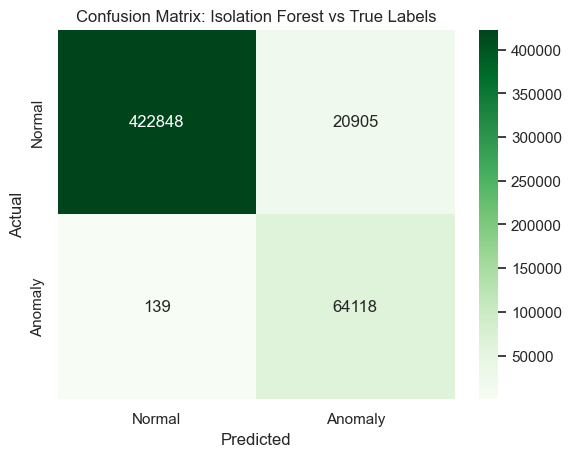

In [295]:
cm = confusion_matrix(df_test["Label"], df_test["pred_anomaly"])
sns.heatmap(cm, annot=True, fmt='d', cmap="Greens", xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Isolation Forest vs True Labels")
plt.show()

#### Visualisation in Feature Space

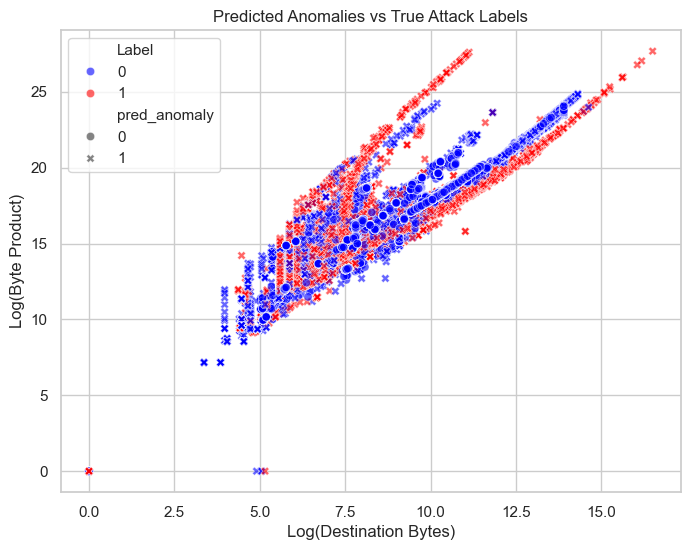

In [296]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_test,
    x="log_dbytes",
    y="log_byte_prod",
    hue="Label",
    style="pred_anomaly",
    alpha=0.6,
    palette={0: "blue", 1: "red"}
)
plt.xlabel("Log(Destination Bytes)")
plt.ylabel("Log(Byte Product)")
plt.title("Predicted Anomalies vs True Attack Labels")
plt.show()

### Error Analysis

#### Create Outcome Categories

In [298]:
df_test["outcome"] = "TN" # Default
df_test.loc[(df_test["Label"] == 1) & (df_test["pred_anomaly"] == 1), "outcome"] = "TP"
df_test.loc[(df_test["Label"] == 1) & (df_test["pred_anomaly"] == 0), "outcome"] = "FN"
df_test.loc[(df_test["Label"] == 0) & (df_test["pred_anomaly"] == 1), "outcome"] = "FP"

# Sanity check
display(df_test["outcome"].value_counts())

outcome
TN    422848
TP     64118
FP     20905
FN       139
Name: count, dtype: int64

#### Create Attack Subset

In [299]:
attack_subset = df_test[df_test["Label"] == 1]
attack_subset = attack_subset.reset_index(drop=True)

#### Feature Medians by Outcome for Attacks

,log_dbytes,log_min_flow_bytes,log_byte_prod
outcome,,,
FN,5.872118,5.872118,12.204356
TP,0.000000,0.000000,0.000000


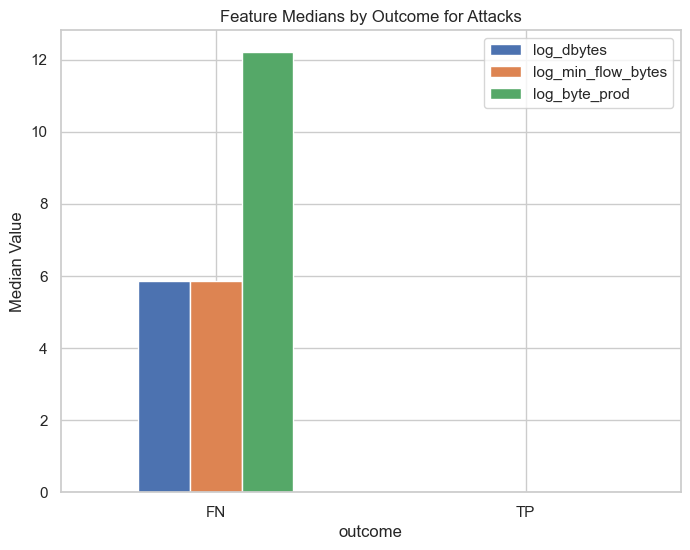

In [300]:
features_of_interest = [
    "log_dbytes",
    "log_min_flow_bytes",
    "log_byte_prod"
]
attack_summary = (
    attack_subset
    .groupby("outcome")[features_of_interest]
    .median()
    .sort_index()
)
display(attack_summary)

# Visual comparison
attack_summary.plot(
    kind="bar",
    figsize=(8, 6),
    title="Feature Medians by Outcome for Attacks",
)
plt.ylabel("Median Value")
plt.xticks(rotation=0)
plt.show()

**Observations:**
- True positives align with the majority of malicious flows, exhibiting extremely low volume feature values (e.g., near-zero destination bytes).
- False negatives occur when attacks resemble normal flows, showing higher byte volumes.
- The main low-volume signal identified during EDA is well represented across these three features.

#### Visualise Errors in Feature Space

Visualizing detected vs missed attacks in 2D feature space. This shows how missed attacks may blend in with normal traffic along these features.

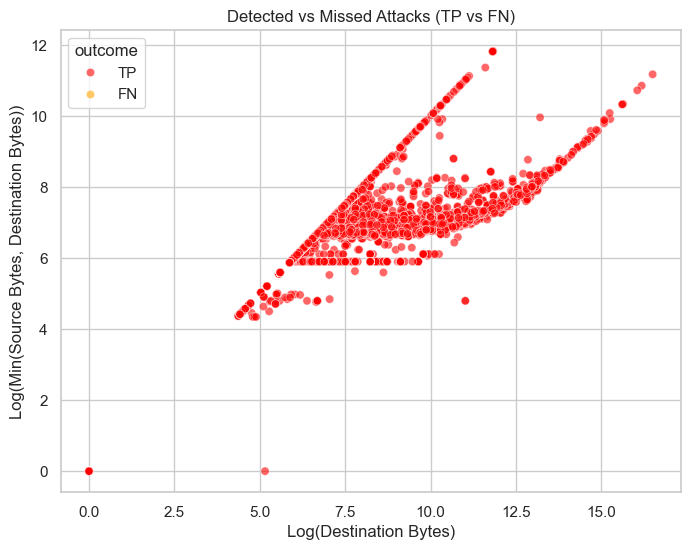

In [304]:
# Multi-feature scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=attack_subset,
    x="log_dbytes",
    y="log_min_flow_bytes",
    hue="outcome",
    palette={"TP": "red", "FN": "orange"},
    alpha=0.6
)
plt.xlabel("Log(Destination Bytes)")
plt.ylabel("Log(Min(Source Bytes, Destination Bytes))")
plt.title("Detected vs Missed Attacks (TP vs FN)")
plt.show()

Boxplots highlight median, spread, and potential outliers, helping identify why some attacks are missed.

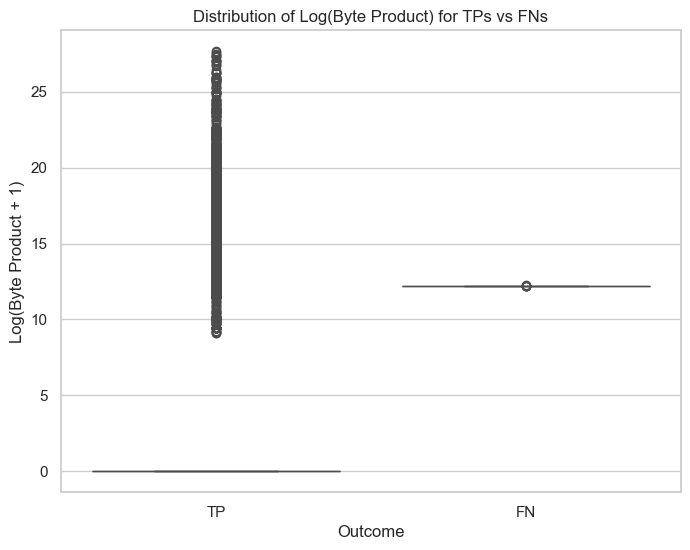

In [306]:
# Single-feature boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(
    x="outcome",
    y="log_byte_prod",
    data=attack_subset
)
plt.xlabel("Outcome")
plt.ylabel("Log(Byte Product + 1)")
plt.title("Distribution of Log(Byte Product) for TPs vs FNs")
plt.show()

### Score-Based Evaluation (Appendix / Exploratory)

#### Score Distribution

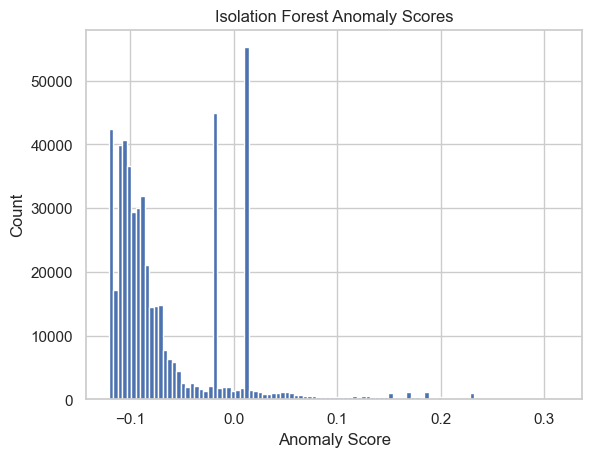

In [307]:
plt.hist(anomaly_scores, bins=100)
plt.xlabel("Anomaly Score")
plt.ylabel("Count")
plt.title("Isolation Forest Anomaly Scores")
plt.show()

#### Precision-Recall Curve

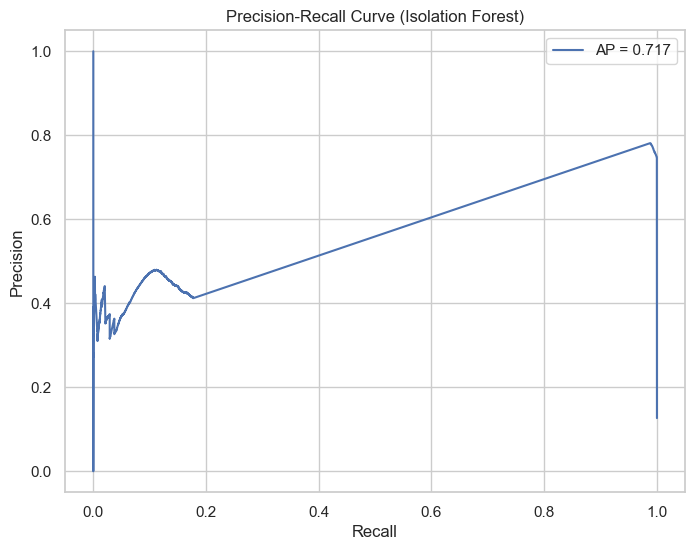

In [308]:
precision, recall, thresholds = precision_recall_curve(y_test, anomaly_scores)
ap = average_precision_score(y_test, anomaly_scores)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"AP = {ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Isolation Forest)")
plt.legend()
plt.grid(True)
plt.show()

#### ROC Curve

The ROC curve is included for completeness as a threshold-independent measure of score separability. However, due to the strong class imbalance in intrusion detection, precision–recall analysis is more informative for evaluating operational performance.

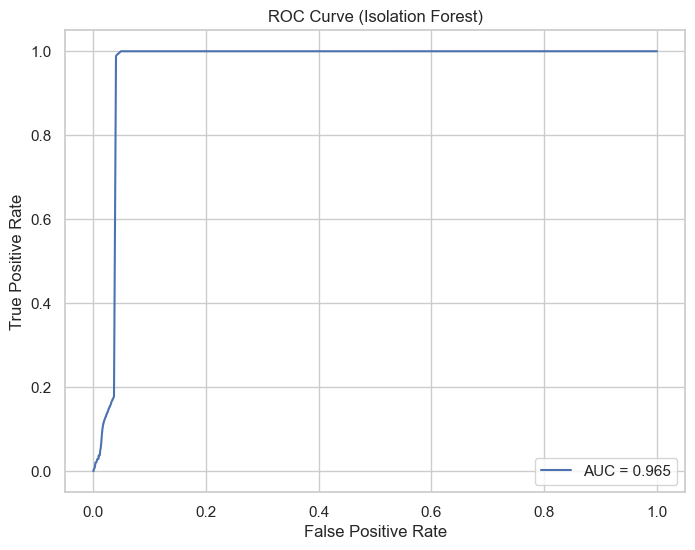

In [309]:
fpr, tpr, thresholds = roc_curve(y_test, anomaly_scores)
roc_auc = roc_auc_score(y_test, anomaly_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Isolation Forest)")
plt.legend()
plt.grid(True)
plt.show()

# Export Flagged Flow Dataset

In [310]:
# Save df_test to CSV for attack subset analysis
anomalies_path = Path("../data/processed/stage1_anomalies.csv")
df_test[df_test["pred_anomaly"] == 1].to_csv(anomalies_path, index=False)